# Frontier: PLAN 09 vanishing cocycle for the actual high-escaping cover

This notebook isolates the **live mathematical frontier** after the abstract Čech-gluing step was formalized in Lean. Its only purpose is to track the remaining theorem that must be proved for the actual high-escaping chart cover.


## Precise frontier theorem

Let

$$
U_0,\dots,U_m \subset \mathbf C^*, \qquad \Omega = \bigcup_{j=0}^m U_j,
$$

be the actual high-escaping chart cover attached to a sufficiently large level-$K$ loop image, and let

$$
b_j : U_j \to \mathbf C
$$

be the actual logarithm branches obtained by continuation of the same normalized near-infinity germ. On every nonempty overlap define the transition difference

$$
c_{jk} = b_k - b_j \quad \text{on } U_j \cap U_k.
$$

Because $e^{b_j}=e^{b_k}=w$ on overlaps, each $c_{jk}$ takes values in $2\pi i \mathbf Z$, so these differences form a Čech $1$-cocycle with coefficients in the locally constant sheaf $2\pi i \mathbf Z$.

The live theorem is:

$$
[c_{jk}] = 0 \in \check H^1(\Omega, 2\pi i \mathbf Z).
$$

Equivalently, one must show that there exist constants $a_j \in 2\pi i \mathbf Z$ such that

$$
c_{jk} = a_k - a_j
$$

on all relevant overlaps of the actual cover.


## Why this is the remaining gap

The abstract implication

$$
[c_{jk}] = 0 \Longrightarrow b_m=b_0 \text{ on } V_{\mathrm{cl}}
$$

is already formalized in Lean as `Quadratic.logBranch_eqOn_closing_of_coboundary`. So the repository is **not** missing another abstract uniqueness theorem or another gluing argument.

What is still missing is the genuinely dynamical input: prove that the **actual high-escaping geometry** forces the transition cocycle of the actual local branches to vanish.

The companion notebook `notebooks/plan09_actual_overlap_neighborhoods_companion.ipynb` keeps the closing theorem, the rigorous Čech-gluing criterion, the one-domain proof, and the easy positive examples. This frontier notebook isolates only the theorem that remains open.


## Lean-facing completion criterion

A satisfactory completion should produce the actual chart data together with a coboundary witness for the transition cocycle, in a form that feeds the existing PLAN 08/09 interfaces. Concretely, the target is to bridge the actual high-escaping chart cover to the already formalized theorem

`Quadratic.logBranch_eqOn_closing_of_coboundary`

and then package the result back into the chart-chain wrappers

```lean
HighEscapingActualChartChainsEqOnOverlapNeighborhoodData
HighEscapingActualChartChainsEventuallyEqAtOverlapsData
HighEscapingActualChartChainsProductComparisonData
```

so that PLAN 08 can consume the closing equality without adding any new abstract monodromy axioms.


## Concrete subproblems for the actual geometry

1. Choose the actual high-escaping charts $U_j$ and overlap neighborhoods with enough connectedness control to make the transition functions unambiguous.
2. Define the actual normalized local logarithm branches $b_j$ on those charts.
3. Show that on every overlap the difference $b_k-b_j$ is the relevant constant element of $2\pi i \mathbf Z$.
4. Prove that the resulting cocycle class on the finite overlap nerve is zero.
5. Extract the coboundary constants $a_j$ and invoke the checked Lean theorem for the closing overlap.

This is the frontier that remains after the abstract Čech-gluing step has been discharged.


## Sketch of a proof route for the live theorem

The classical implication

$$
[c_{jk}] = 0 \Longrightarrow b_m=b_0 \text{ on } V_{\mathrm{cl}}
$$

is already settled. So the live theorem must supply the missing geometric input: show that the **actual** transition cocycle of the high-escaping cover is already a coboundary.

A plausible proof route is to prove a stronger statement than the notebook's formal target.

1. **Produce one simply connected zero-free neighborhood of the whole high-escaping image.** For sufficiently large $K$, prove that the actual loop image $A_K([0,1])$ is contained in an open set
   $$
   W \subset \mathbf C^*
   $$
   that is simply connected. In practice, one expects $W$ to come from a high-escaping right-half-plane or slit-plane estimate.
2. **Choose one global logarithm on $W$.** By the standard global-logarithm criterion on simply connected domains, there exists a holomorphic branch
   $$
   L:W \to \mathbf C, \qquad e^{L(w)}=w.
   $$
3. **Compare the actual local branches with $L$.** Since each actual branch $b_j$ is obtained by continuation of the same normalized near-infinity germ, and $L$ extends that same germ on $W$, the identity principle should give
   $$
   b_j = L\vert_{U_j}
   $$
   on every chart of the actual cover.
4. **Conclude that all transition constants vanish.** On every overlap,
   $$
   c_{jk}=b_k-b_j = L\vert_{U_k}-L\vert_{U_j}=0.
   $$
   Hence the cocycle is not merely a coboundary: it is the zero cocycle, so one may take
   $$
   a_j=0 \qquad (0 \le j \le m).
   $$
5. **Invoke the checked abstract theorem.** The already formalized Lean theorem `Quadratic.logBranch_eqOn_closing_of_coboundary` then yields the closing equality.

So the hard point is not the Čech step anymore. The hard point is to obtain, from the **actual high-escaping geometry**, a simply connected zero-free neighborhood $W$ containing the whole image, or an equivalent argument that forces the winding/monodromy around $0$ to be zero.


## Rigorous proof target implementing the sketch

The unconditional proof should not stop after assuming a global logarithm. It should prove exactly the global-log data needed from the actual high-escaping geometry and then apply the already checked Čech-closing theorem. Written as a theorem-shaped proof, the remaining dynamical work is Step 1 below.

**Theorem (live vanishing-cocycle theorem).** For the actual high-escaping image
$$
A_K(t)=\operatorname{logSeriesBottcherApprox}\bigl(2,f_2^K(\gamma(t))\bigr),\qquad 0\le t\le 1,
$$
and the actual finite chart cover
$$
(U_j,V_j,b_j)_{0\le j\le m},
$$
the transition cocycle
$$
c_{jk}=b_k-b_j\in 2\pi i\mathbf Z
$$
has zero class:
$$
[c_{jk}]=0\in \check H^1(\Omega,2\pi i\mathbf Z).
$$
Consequently the closing equality $b_m=b_0$ holds on $V_{\mathrm{cl}}$.

**Proof.**

1. **Dynamical global-log theorem.** Prove from high-escaping estimates that, for sufficiently large $K$, there exist:
   $$
   \Omega\subset \mathbf C^*
   $$
   a connected open neighborhood of $A_K([0,1])$,
   $$
   L:\Omega\to\mathbf C,
   $$
   holomorphic with $e^{L(w)}=w$ on $\Omega$, and a nonempty open anchor set
   $$
   B\subset \Omega
   $$
   on which $L$ agrees with the normalized near-infinity logarithm germ used to define the actual branches. Equivalently, one may prove first that the actual image has trivial winding around $0$:
   $$
   \operatorname{wind}(A_K,0)=0.
   $$
   Then one still has to extract the anchored logarithm data above. Concrete sufficient routes are:
   $$
   A_K([0,1])\subset W\subset\mathbf C^*
   $$
   for some simply connected open set $W$ meeting the normalization region, or construct a zero-free homotopy
   $$
   H:[0,1]^2\to\mathbf C^*,\qquad H(0,t)=A_K(t),
   $$
   from $A_K$ to a constant or near-infinity reference loop inside a zero-free region where the normalized branch is already fixed. A right-half-plane estimate, a rotated slit-plane estimate, or an explicit zero-free homotopy would each prove this step. This is the genuinely dynamical part of the proof: it rules out the only obstruction to a single-valued logarithm and fixes the correct additive normalization.

2. **Use the anchored logarithm from Step 1.** By Step 1, there is a connected zero-free neighborhood
   $$
   \Omega\subset\mathbf C^*
   $$
   with $A_K([0,1])\subset \Omega$ and a holomorphic branch
   $$
   L:\Omega\to\mathbf C,\qquad e^{L(w)}=w.
   $$
   By construction, $L$ already has the same normalization as the actual branches on the anchor set $B$.

3. **Refine the actual cover inside $\Omega$.** Since $A_K([0,1])$ is compact and contained in the open set $\Omega$, shrink/refine the finite chart cover so that
   $$
   U_j\subset \Omega,
   $$
   the overlap neighborhoods satisfy
   $$
   V_j\subset U_j\cap U_{j+1},\qquad V_{\mathrm{cl}}\subset U_m\cap U_0,
   $$
   and every $U_j$ remains connected and zero-free.

4. **Identify each actual branch with the global branch.** On each connected $U_j$, both $b_j$ and $L|_{U_j}$ are holomorphic logarithms of the identity. Their germs agree on the nonempty set where the continuation path first enters $U_j$: the actual branch $b_j$ is, by construction, the continuation of the normalized branch, while $L$ has the same normalization on the anchor set $B$ and hence on every continuation of that germ inside $\Omega$. By analytic continuation and the identity theorem,
   $$
   b_j=L|_{U_j}\qquad\text{on }U_j.
   $$

5. **Compute the cocycle.** On every overlap,
   $$
   c_{jk}=b_k-b_j=L|_{U_k}-L|_{U_j}=0.
   $$
   Hence the cocycle is the zero cocycle. In the notation of the checked Lean theorem `Quadratic.logBranch_eqOn_closing_of_coboundary`, take
   $$
   a_j=0\in 2\pi i\mathbf Z\qquad(0\le j\le m).
   $$

6. **Close the chain.** The hypotheses of `Quadratic.logBranch_eqOn_closing_of_coboundary` are now satisfied, so
   $$
   b_m=b_0\qquad\text{on }V_{\mathrm{cl}}.
   $$

This is the rigorous shape of the unconditional proof. The proof is complete once Step 1 is proved as a dynamical theorem for the actual high-escaping image; after that, the remaining steps are classical analytic continuation / identity-theorem / Čech bookkeeping already aligned with the formalized Lean interface.


## Literature notes

The literature search suggests a clear split between what is classical and what still appears specific to this project.

### Classical general criterion

1. **Global logarithms on simply connected zero-free domains.** Standard complex-analysis references such as Conway, Ahlfors, and Rudin prove: if $W \subset \mathbf C^*$ is simply connected, then the identity map on $W$ admits a holomorphic logarithm. This is the analytic core behind the sketch above.
2. **Exponential sheaf sequence / Čech viewpoint.** References such as Forster's *Lectures on Riemann Surfaces* and Gunning's *Lectures on Riemann Surfaces* treat the exact sequence
   $$
   0 \to 2\pi i \mathbf Z \to \mathcal O \xrightarrow{\exp} \mathcal O^* \to 0
   $$
   and the resulting cohomological obstruction to gluing local logarithms. In that language, the class $[c_{jk}] \in \check H^1(\Omega,2\pi i\mathbf Z)$ is the standard obstruction to a global log.
3. **Monodromy / winding-number interpretation.** Classical monodromy theorems identify the obstruction with nontrivial continuation around loops, equivalently a nonzero winding number around $0$ in $\mathbf C^*$.

### Related complex-dynamics uses

1. **Böttcher-coordinate extension.** Milnor's *Dynamics in One Complex Variable* and Douady-Hubbard's *Étude dynamique des polynômes complexes* use local-to-global extension arguments for Böttcher coordinates in polynomial basins. These arguments are very close in spirit to the present route, even when they are not phrased in explicit Čech language.
2. **Puzzle / basin gluing arguments.** The complex-dynamics literature repeatedly uses uniqueness of analytic continuation and trivial monodromy to glue local branches, but usually at a higher level of abstraction than the finite-cover cocycle statement isolated here.

### What seems not to be covered already

The search did **not** reveal a standard reference that proves, in the exact finite-cover form needed here, that the cocycle of an **actual dynamically constructed high-escaping chart cover** vanishes purely from the geometric overlap data of that cover. The classical criterion is standard; the apparent novelty is the dynamical step that upgrades the actual high-escaping geometry to that criterion, together with the explicit Lean packaging of the result.

For the present notebook, the most useful references are:

- **Conway**, *Functions of One Complex Variable* — global logarithms and monodromy.
- **Ahlfors**, *Complex Analysis* — analytic continuation, logarithms, winding number.
- **Forster**, *Lectures on Riemann Surfaces* — exponential sheaf sequence and the cohomological obstruction.
- **Milnor**, *Dynamics in One Complex Variable* — Böttcher coordinates and basin extension.
- **Douady-Hubbard**, *Étude dynamique des polynômes complexes* — the original polynomial-dynamics version of the local-to-global Böttcher story.


## Plan-level interpretation

PLAN 09 should now be read in two layers.

1. **Companion notebook layer:** `plan09_actual_overlap_neighborhoods_companion.ipynb` records the closing theorem and the already-settled abstract reduction.
2. **Live frontier layer:** this notebook records the still-open theorem that the actual high-escaping cover has vanishing transition-cocycle class.

Any further progress on the PLAN 09 frontier should update this notebook directly, since this is where the genuinely open theorem is now isolated. This frontier notebook points back to the companion notebook for the abstract closing step and the model examples.


## Numerical counterexample attempt for the live theorem

A synthetic counterexample is easy to fake on paper: take a circular cover of a loop in $\mathbf C^*$ and manually shift one local logarithm branch by $2\pi i$, so that one transition constant is nonzero and the resulting Čech class is not a coboundary. Numerically this produces a nontrivial cocycle immediately.

But that does **not** contradict the live theorem, because it breaks the key hypothesis: the branches are no longer all obtained by continuation of the **same normalized near-infinity germ** on the **actual high-escaping chart cover**. It is only a manufactured failure of compatibility.

So an honest numerical counterexample to the live theorem is not available here: any numerical failure we can force by hand leaves the class of covers/branches that the theorem is actually about. For that reason, the most informative notebook experiment is a positive model example where the cocycle is visibly zero.

## Illustrative positive numerical example

Use the loop

$$
A(t)=0.25+0.9\cos(2\pi t)+i\bigl(0.75+0.55\sin(2\pi t)\bigr), \qquad 0 \le t \le 1.
$$

This loop is genuinely different from the companion-notebook circle: it enters the **left half-plane**, but it still stays away from both $0$ and the negative real axis. Hence the principal logarithm is defined on the slit plane $\mathbf C \setminus (-\infty,0]$, which contains the whole loop image.

We cover the loop by four overlapping disks $U_0,U_1,U_2,U_3$ and restrict the principal logarithm to each chart. The next cell checks numerically that the loop avoids the branch cut, verifies that each quarter-arc is contained in its disk, computes sample transition constants on the overlaps, and plots the loop, the cover, and the branch cut.

min |A(t)| on the loop: 0.2187
min |Im A(t)| where Re A(t) <= 0: 0.2218
quarter-arc 0 covered by U_0: True
quarter-arc 1 covered by U_1: True
quarter-arc 2 covered by U_2: True
quarter-arc 3 covered by U_3: True
overlap $U_0 \cap U_1$ sample point = (0.25000000000000006+1.3j)
transition constant at sample point: 0j
overlap $U_1 \cap U_2$ sample point = (-0.65+0.7500000000000001j)
transition constant at sample point: 0j
overlap $U_2 \cap U_3$ sample point = (0.24999999999999983+0.19999999999999996j)
transition constant at sample point: 0j
closing overlap $U_3 \cap U_0$ sample point = (1.15+0.75j)
transition constant at sample point: 0j


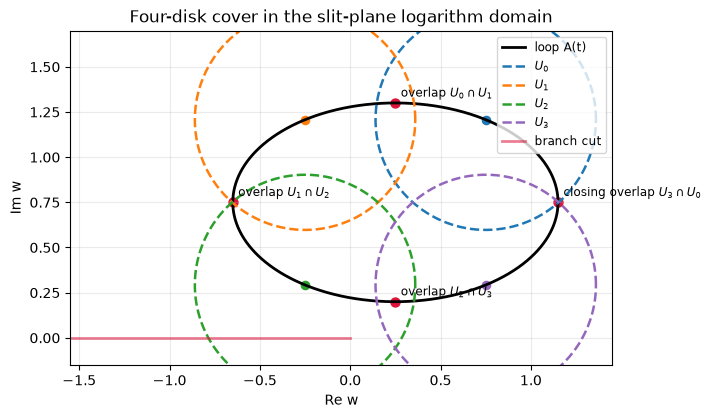

In [1]:
import numpy as np
import matplotlib.pyplot as plt


def A(t):
    theta = 2.0 * np.pi * t
    return 0.25 + 0.9 * np.cos(theta) + 1j * (0.75 + 0.55 * np.sin(theta))


def principal_log(z):
    return np.log(np.abs(z)) + 1j * np.angle(z)


t = np.linspace(0.0, 1.0, 1601)
curve = A(t)

centers = np.array([
    0.75001321 + 1.20730829j,
    -0.25001321 + 1.20730829j,
    -0.25001321 + 0.29269171j,
    0.75001321 + 0.29269171j,
], dtype=np.complex128)
radius = 0.61
parts = [(0.0, 0.25), (0.25, 0.5), (0.5, 0.75), (0.75, 1.0)]
labels = [r"$U_0$", r"$U_1$", r"$U_2$", r"$U_3$"]
colors = ["tab:blue", "tab:orange", "tab:green", "tab:purple"]

overlap_points = [A(0.25), A(0.5), A(0.75), A(0.0)]
overlap_names = [
    r"overlap $U_0 \cap U_1$",
    r"overlap $U_1 \cap U_2$",
    r"overlap $U_2 \cap U_3$",
    r"closing overlap $U_3 \cap U_0$",
]

cover_checks = []
for center, (a, b) in zip(centers, parts):
    mask = (t >= a) & (t <= b)
    cover_checks.append(np.all(np.abs(curve[mask] - center) < radius))

left_half_mask = curve.real <= 0.0
min_imag_on_left = np.min(np.abs(curve.imag[left_half_mask]))
min_abs_value = np.min(np.abs(curve))

transition_samples = []
for point in overlap_points:
    b_left = principal_log(point)
    b_right = principal_log(point)
    transition_samples.append(b_right - b_left)

print(f"min |A(t)| on the loop: {min_abs_value:.4f}")
print(f"min |Im A(t)| where Re A(t) <= 0: {min_imag_on_left:.4f}")
for j, ok in enumerate(cover_checks):
    print(f"quarter-arc {j} covered by U_{j}: {ok}")
for name, point, c in zip(overlap_names, overlap_points, transition_samples):
    print(f"{name} sample point = {point}")
    print(f"transition constant at sample point: {c}")

fig, ax = plt.subplots(figsize=(7.2, 6.2))
ax.plot(curve.real, curve.imag, color="black", linewidth=2.0, label="loop A(t)")

angles = np.linspace(0.0, 2.0 * np.pi, 400)
for center, color, label in zip(centers, colors, labels):
    circle = center + radius * np.exp(1j * angles)
    ax.plot(circle.real, circle.imag, linestyle="--", color=color, linewidth=1.8, label=label)
    ax.scatter([center.real], [center.imag], color=color, s=35)

for point, label in zip(overlap_points, overlap_names):
    ax.scatter([point.real], [point.imag], color="crimson", s=42)
    ax.text(point.real + 0.03, point.imag + 0.03, label, fontsize=8.7)

branch_cut_x = np.linspace(-1.55, 0.0, 200)
ax.plot(branch_cut_x, np.zeros_like(branch_cut_x), color="crimson", linewidth=2.0, alpha=0.55, label="branch cut")

ax.set_aspect("equal", adjustable="box")
ax.set_xlim(-1.55, 1.45)
ax.set_ylim(-0.15, 1.7)
ax.set_xlabel("Re w")
ax.set_ylabel("Im w")
ax.set_title("Four-disk cover in the slit-plane logarithm domain")
ax.grid(alpha=0.25)
ax.legend(loc="upper right", fontsize=8.5)
plt.tight_layout()
plt.show()


## Explanation of the positive example

This plot shows a loop whose image is **not** confined to the right half-plane: it passes through the left half-plane, so it is visibly different from the companion-notebook example. The red horizontal segment marks the forbidden branch cut $(-\infty,0]$. The numerical checks show that the loop stays a definite distance away from both the origin and that cut, so the principal logarithm remains valid on a slit-plane neighborhood of the entire image.

Each dashed circle is one chart of a four-piece cover, and the red points mark sample points in the three interior overlaps and in the closing overlap. Because all local branches are restrictions of the same principal logarithm, the sampled transition constants are again zero. The point of this example is different from the companion one: it illustrates cocycle vanishing on a cover that is **more global than a half-plane picture**, while still avoiding the branch cut in a controlled way.